# S4 — analiza sistematičnih parametrskih preizkusov

## Kako se ta zvezek uporablja in kaj točno dela

**Kaj dela.** Zvezek je analitična plast nad enotno tabelo rezultatov
(`docs/REZULTATI_SHEMA.md`): prebere `reports/results_master.csv` (ali jo sam
zlepi iz posameznih `results/**/results.csv`, če glavna tabela še ne obstaja),
združi ponovitve istega eksperimenta čez semena v povprečje s 95-odstotnim
Studentovim t intervalom zaupanja, nariše štiri načrtovane slike poročila
(vodilna metrika glede na ε, glede na napadalčevo predznanje, primerjava
mehanizmov, računski čas) ter pregleda prekoračitve računskega proračuna
300 sekund na zagon napada. Slike shrani v `reports/s4_figures/` in jih
prikaže v zvezku.

**Česa ne dela.** Ničesar ne poganja in ne piše v `results/` — je samo bralec.
Eksperimente poganjaš prej v terminalu (glej `docs/RUNNING.md` §7.1):

    uv run trajguard repeat config/experiments/<ime>.yaml --seeds 1 2 3 4 5
    uv run trajguard report        # zlepi glavno tabelo (ni obvezno; zvezek jo zna sam)

**Kako ga poženeš.** Interaktivno (VS Code ali `uv run --with jupyterlab
jupyter lab`), ali headless — izvede vse celice in shrani izhode v datoteko:

    uv run jupyter nbconvert --to notebook --execute --inplace notebooks/03_s4_sweep.ipynb

**Opozorili.**

1. Zvezek in modul `trajguard.reporting.results_io`, ki ga uporablja, sta
   vezana na glave stolpcev iz `docs/REZULTATI_SHEMA.md` (`RESULTS_COLUMNS`).
   Tabela s tujo glavo je glasna napaka, ne tiho zamaknjeni stolpci — če se
   shema kdaj spremeni, je treba v istem PR posodobiti shemo, bralnik
   `results_io.py` in ta zvezek.
2. Zvezkov ne izvaja nobena avtomatika (CI požene samo `ruff`, `mypy`,
   `pytest`) — po novih zagonih ga osveži ročno z zgornjim nbconvert ukazom.


## 1 · Nastavitev in nalaganje

Poti so relativne na mapo `notebooks/`. Zvezek najprej poskusi z glavno tabelo
`reports/results_master.csv`; če je ni, jo zlepi sam z isto funkcijo, kot jo
uporablja `trajguard report` (`merge_results_tables`), zato je izid enak.


In [1]:
from pathlib import Path

import pandas as pd

from trajguard.reporting.report import merge_results_tables
from trajguard.reporting.results_io import aggregate_over_seeds, read_results_csv

RESULTS_DIR = Path("..") / "results"
REPORTS_DIR = Path("..") / "reports"
FIGURES_DIR = REPORTS_DIR / "s4_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

master = REPORTS_DIR / "results_master.csv"
if not master.exists():
    merged = merge_results_tables(RESULTS_DIR, REPORTS_DIR)
    if merged is None:
        raise FileNotFoundError(
            f"no results.csv under {RESULTS_DIR}/ — run an experiment first: "
            "uv run trajguard run <config>, or trajguard repeat <config> --seeds ..."
        )
    master = merged
records = read_results_csv(master)
print(f"{master}: {len(records)} metric rows")

..\reports\results_master.csv: 876 metric rows


## 2 · Pregled naloženih zagonov

Ena vrstica na kombinacijo (eksperiment, konfiguracija, seme): koliko družin
napadov in koliko vrstic metrik je prispeval posamezen zagon. Če tu manjka
pričakovano seme ali eksperiment, preveri `results/` in po potrebi ponovno
poženi `trajguard report`.


In [2]:
df = pd.DataFrame(
    {
        "exp_id": r.provenance.exp_id,
        "config_hash": r.provenance.config_hash,
        "seed": r.provenance.seed,
        "family": r.row.family,
        "metric": r.row.value.name,
    }
    for r in records
)
df.groupby(["exp_id", "config_hash", "seed"]).agg(
    families=("family", "nunique"), metric_rows=("metric", "size")
).reset_index()

,exp_id,config_hash,seed,families,metric_rows
0,geolife_geoind_reid_u20,56dcf747ce5967f6,1,4,78
1,geolife_geoind_reid_u20,56dcf747ce5967f6,2,4,78
2,geolife_geoind_reid_u20,56dcf747ce5967f6,3,4,78
3,geolife_geoind_reid_u20,56dcf747ce5967f6,4,4,78
4,geolife_geoind_reid_u20,56dcf747ce5967f6,5,4,78
5,geolife_geoind_reid_u50,d2422810aa4a921b,1,4,78
6,geolife_geoind_reid_u50,d2422810aa4a921b,2,4,78
7,geolife_geoind_reid_u50,d2422810aa4a921b,3,4,78
8,geolife_geoind_reid_u50,d2422810aa4a921b,4,4,78
9,geolife_geoind_reid_u50,d2422810aa4a921b,5,4,78


## 3 · Združevanje čez semena

Ponovitve istega eksperimenta (isti `exp_id` in `config_hash`, različna semena)
se združijo v eno vrstico na metriko: vrednost je povprečje, interval pa
**95-odstotni Studentov t interval čez ponovitve**.

**Pomembno — dve vrsti intervalov, ki se ne mešata** (`docs/RUNNING.md` §7.1):
bootstrap interval znotraj enega zagona meri negotovost prevzorčenja, interval
čez semena pa varianco med ponovitvami. Vsi grafi v tem zvezku kažejo
**izključno interval čez semena**. Eksperiment z enim samim semenom dobi
izrojen interval (točko brez razpona) — njegov bootstrap interval si oglej na
grafih posameznega zagona v `results/<eksperiment>/`.


In [3]:
agg_rows = aggregate_over_seeds(records)
print(df.groupby("exp_id")["seed"].nunique().rename("n_seeds").to_string())
print(f"{len(agg_rows)} aggregated (experiment x metric) rows")

# The plot grouping keys (arm_id, target_ref, known_points) ignore exp_id and
# max_users, so mixing sample-ladder rungs in one figure would silently merge
# them. Sections 4-7 therefore draw one figure set per rung, split here.
rungs = sorted({r.provenance.max_users for r in records}, key=lambda u: (u is None, u))
agg_by_rung = {
    u: aggregate_over_seeds([r for r in records if r.provenance.max_users == u]) for u in rungs
}
print("rungs:", {u: len(rows) for u, rows in agg_by_rung.items()})

exp_id
geolife_geoind_reid_u20    5
geolife_geoind_reid_u50    5
geolife_synth_mia_u20      3
geolife_synth_mia_u50      3
188 aggregated (experiment x metric) rows
rungs: {20: 94, 50: 94}


## 4 · Vodilna metrika glede na ε

Osrednje vprašanje poročila (§7.2): kako uspešnost napada pada z močnejšim
šumom (manjši ε). Ena slika na družino napada, os ε je logaritemska; veje brez
ε (surovi podatki, identitetni mehanizem, nezasebni generatorji) na to os ne
sodijo in so izpuščene.

Slike v razdelkih 4–7 so narisane **ločeno za vsako stopnjo lestvice vzorca**
(podmapa `reports/s4_figures/u<stopnja>/`): funkcije risanja stopenj ne ločijo
same, zato bi se zagoni z različnim `max_users` sicer tiho zmešali v isto sliko.


u20: by_epsilon_membership_inference.png


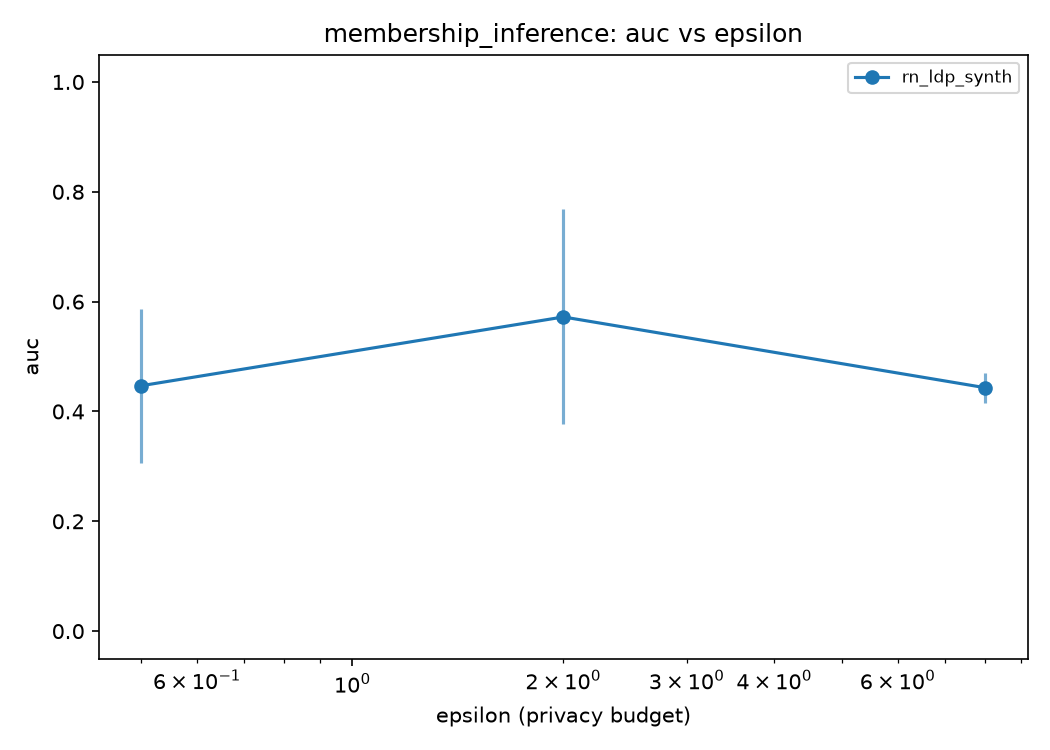

u20: by_epsilon_poi_inference.png


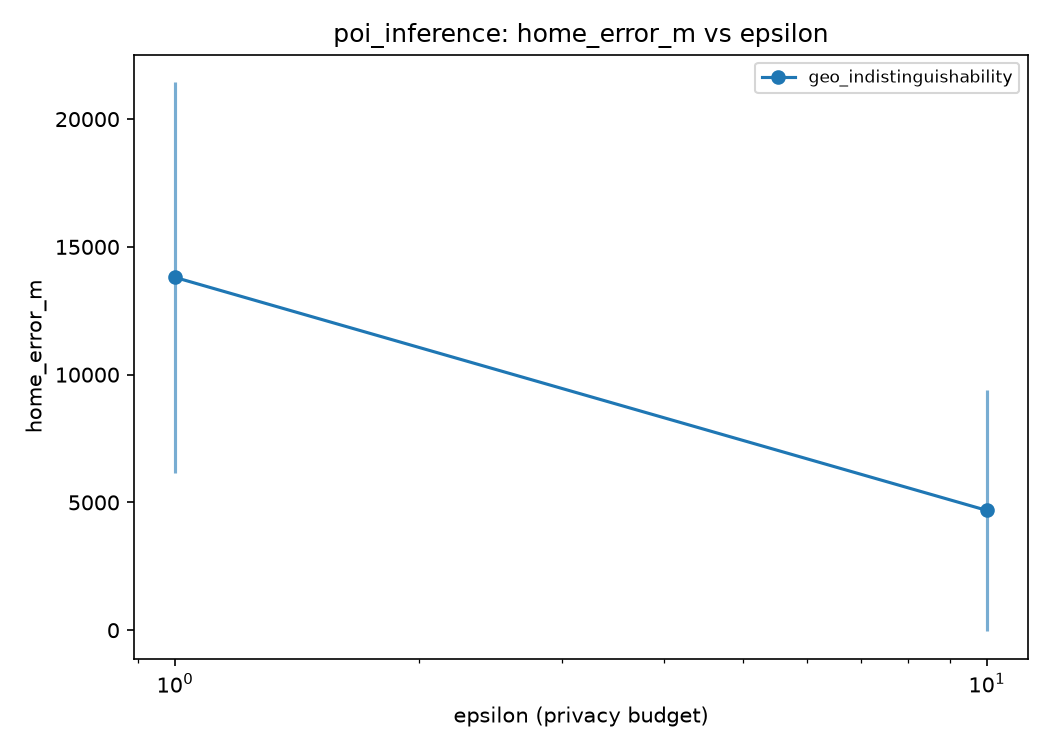

u20: by_epsilon_reconstruction.png


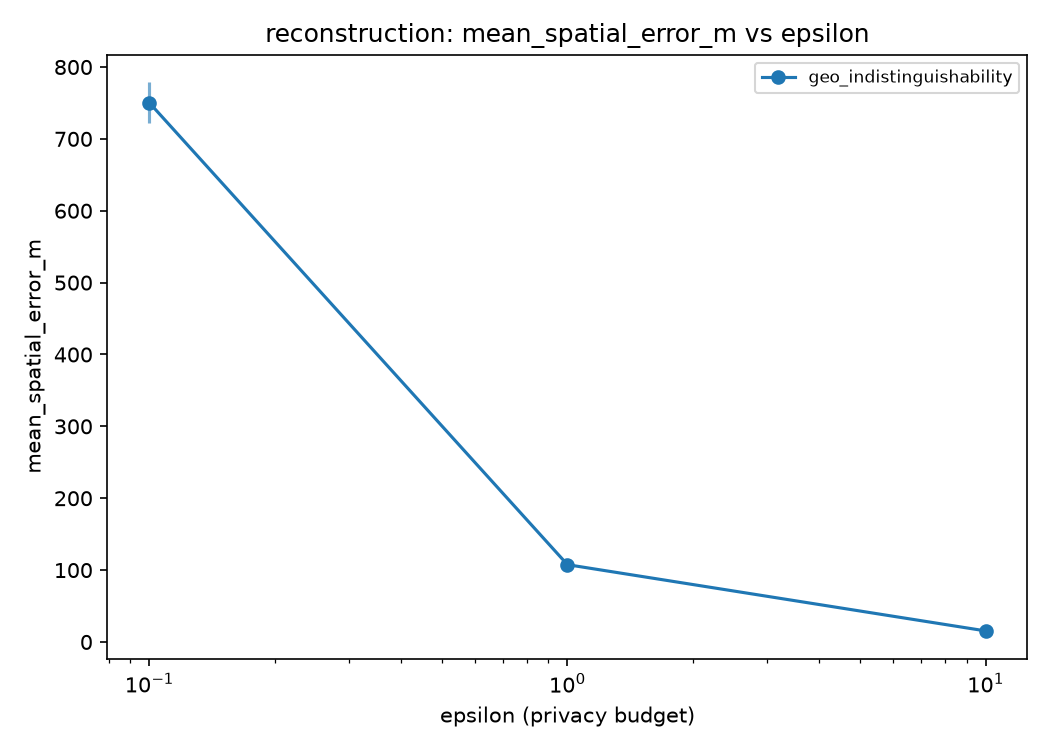

u20: by_epsilon_reidentification.png


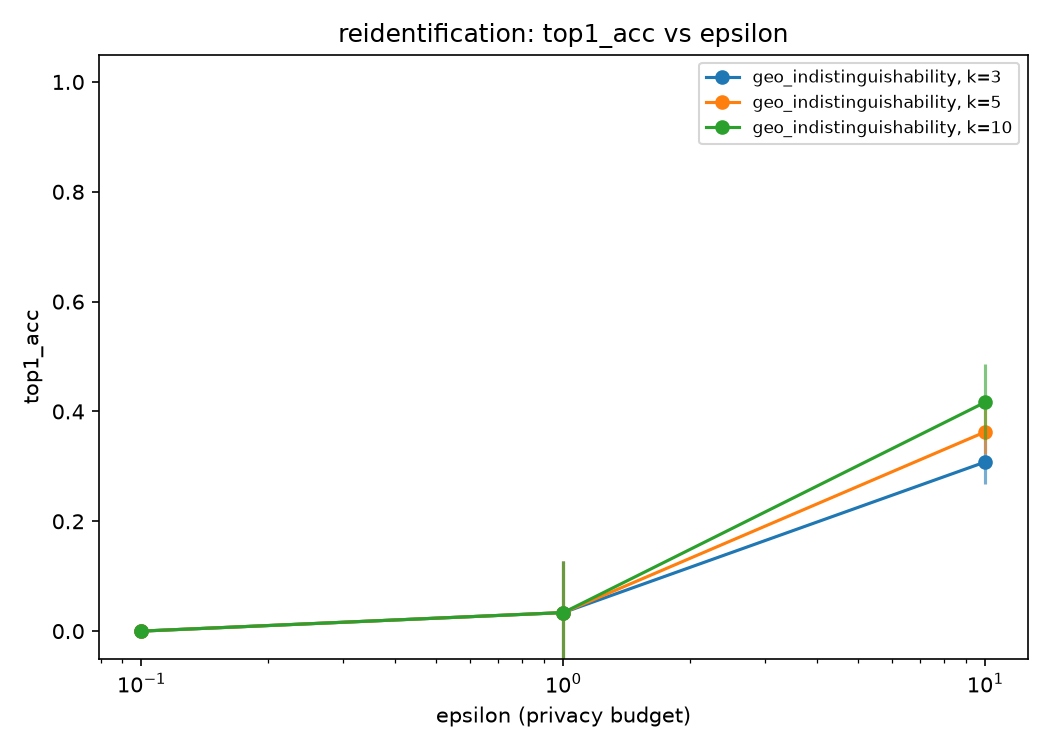

u50: by_epsilon_membership_inference.png


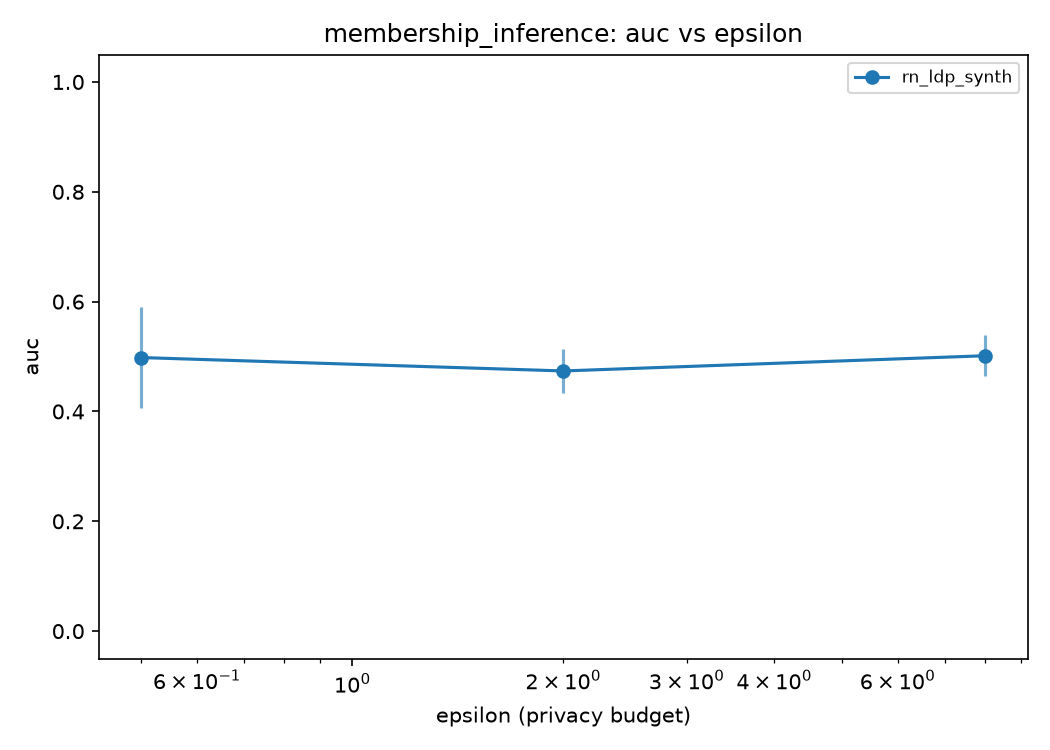

u50: by_epsilon_poi_inference.png


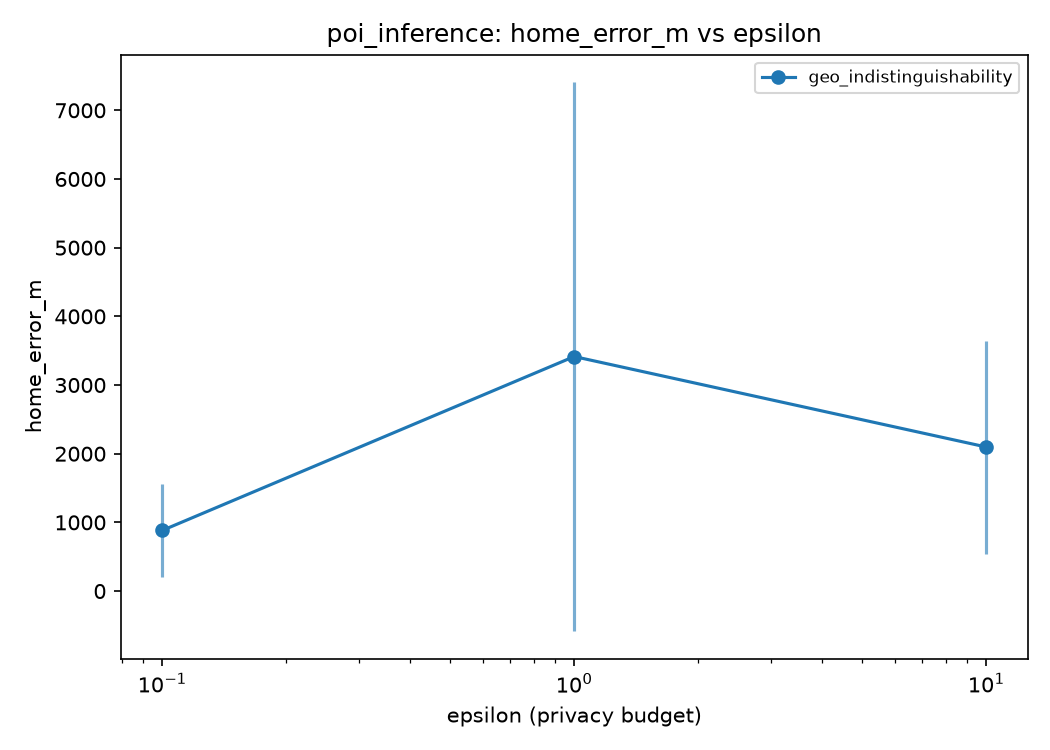

u50: by_epsilon_reconstruction.png


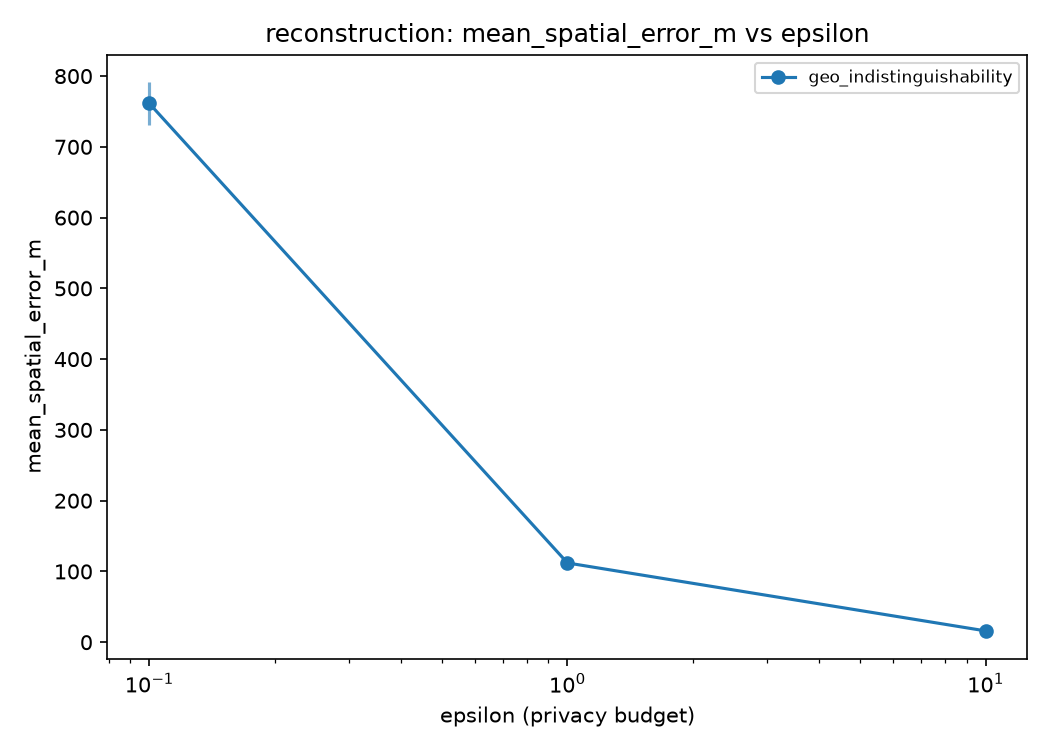

u50: by_epsilon_reidentification.png


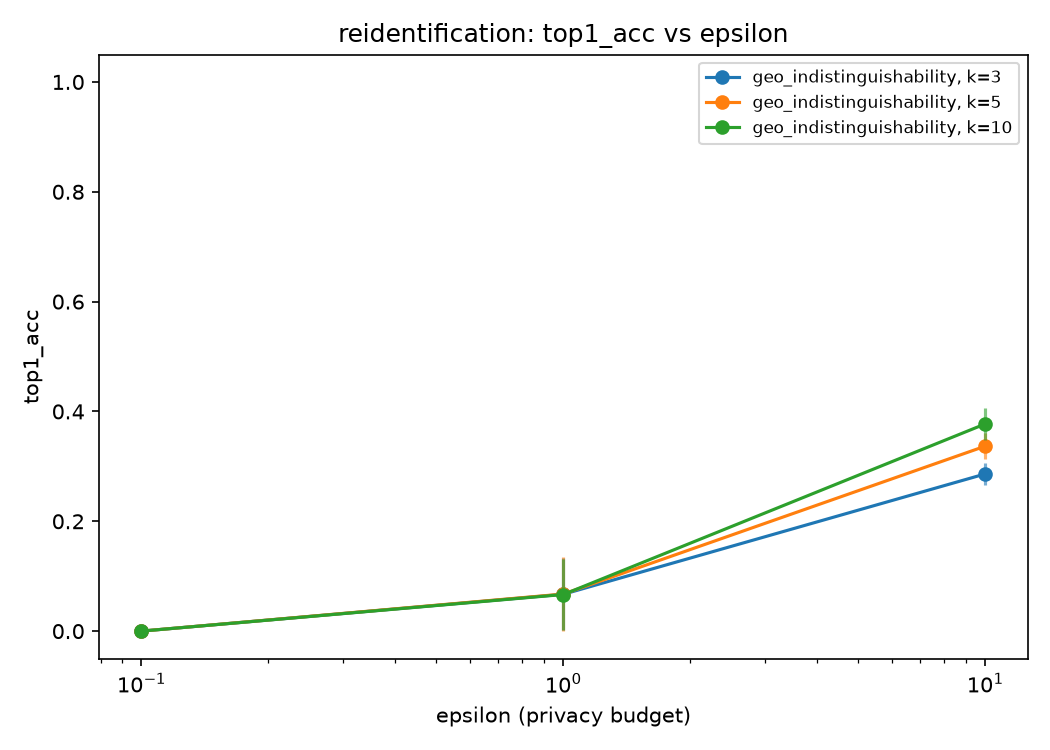

In [4]:
from IPython.display import Image, display

from trajguard.reporting.plots import (
    plot_by_epsilon,
    plot_by_knowledge,
    plot_mechanisms,
    plot_runtime,
)


def rung_dir(rung):
    d = FIGURES_DIR / (f"u{rung}" if rung is not None else "uall")
    d.mkdir(parents=True, exist_ok=True)
    return d


for rung in rungs:
    for path in plot_by_epsilon(agg_by_rung[rung], rung_dir(rung)):
        print(f"u{rung}: {path.name}")
        display(Image(filename=str(path)))

## 5 · Vpliv napadalčevega predznanja

Za družine z gumbom `known_points` (danes reidentifikacija): kako uspešnost
raste s številom točk, ki jih napadalec pozna o tarči. Ena črta na ciljno vejo.


u20: by_knowledge_reidentification.png


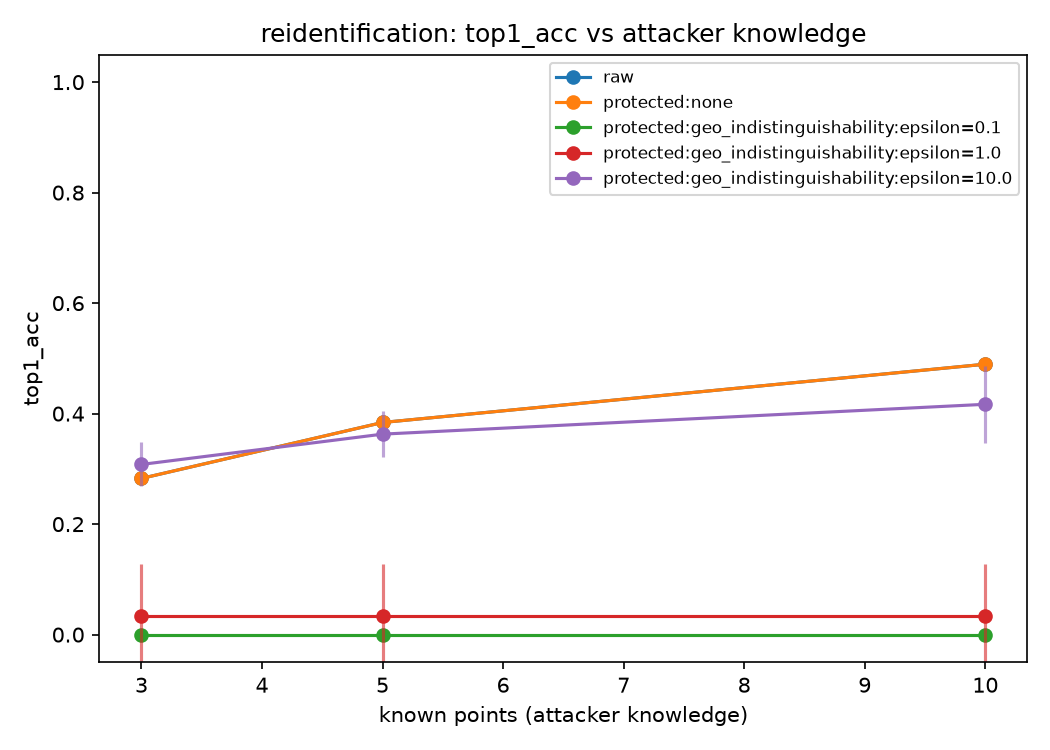

u50: by_knowledge_reidentification.png


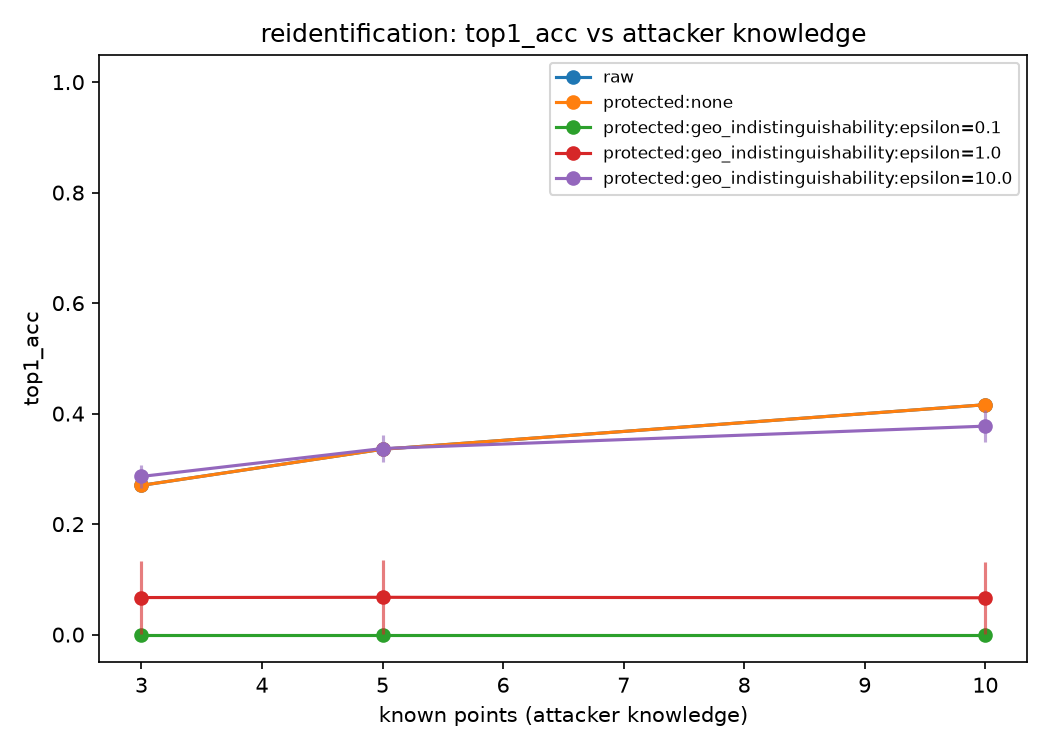

In [5]:
for rung in rungs:
    for path in plot_by_knowledge(agg_by_rung[rung], rung_dir(rung)):
        print(f"u{rung}: {path.name}")
        display(Image(filename=str(path)))

## 6 · Primerjava mehanizmov

Vodoravni stolpci: vodilna metrika družine po vseh vejah (reidentifikacija pri
največjem predznanju), z intervalom čez semena kot brki. To je slika za
neposredno primerjavo zaščitnih mehanizmov v poročilu (§7.3).


u20: mechanisms_membership_inference.png


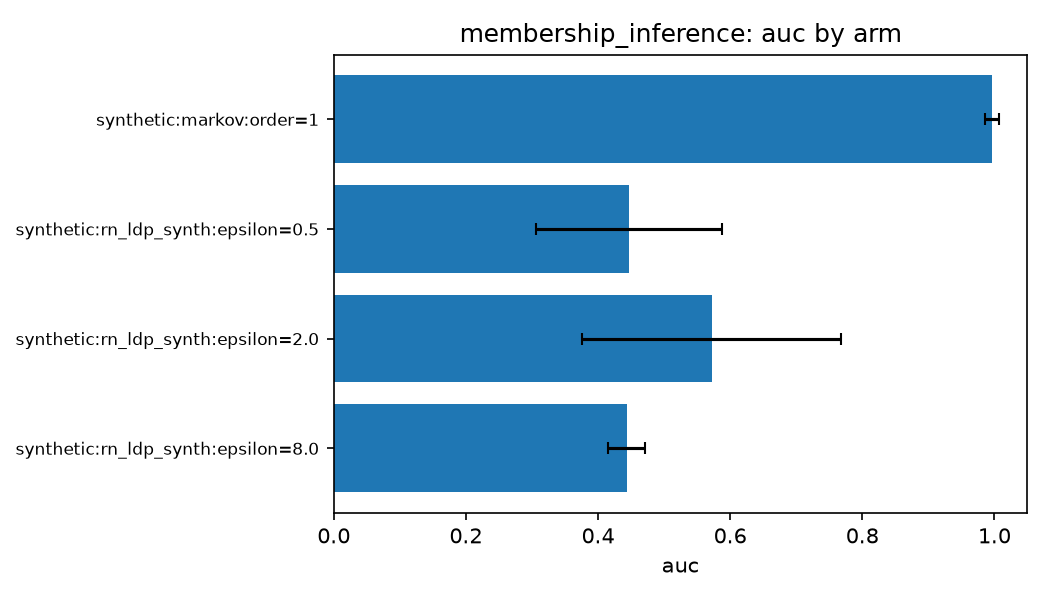

u20: mechanisms_poi_inference.png


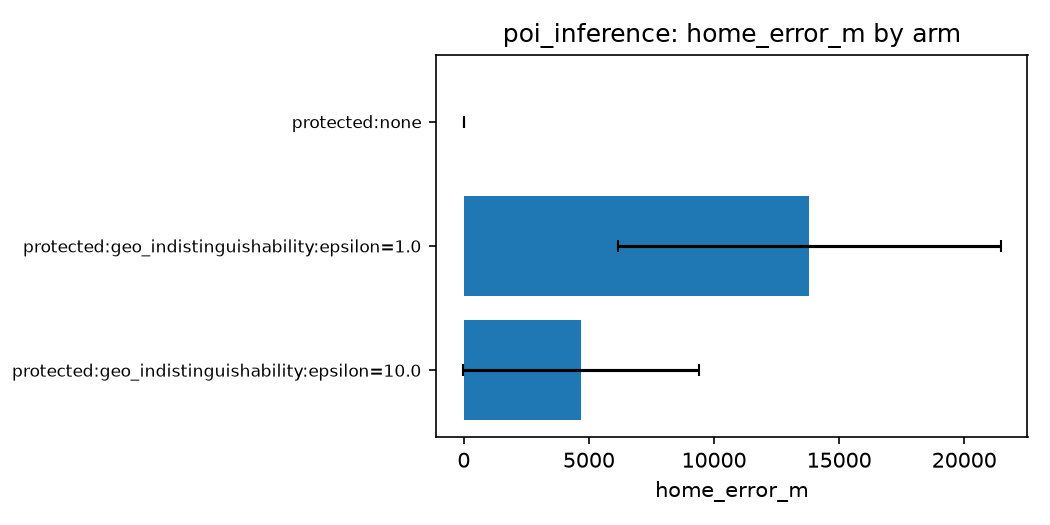

u20: mechanisms_reconstruction.png


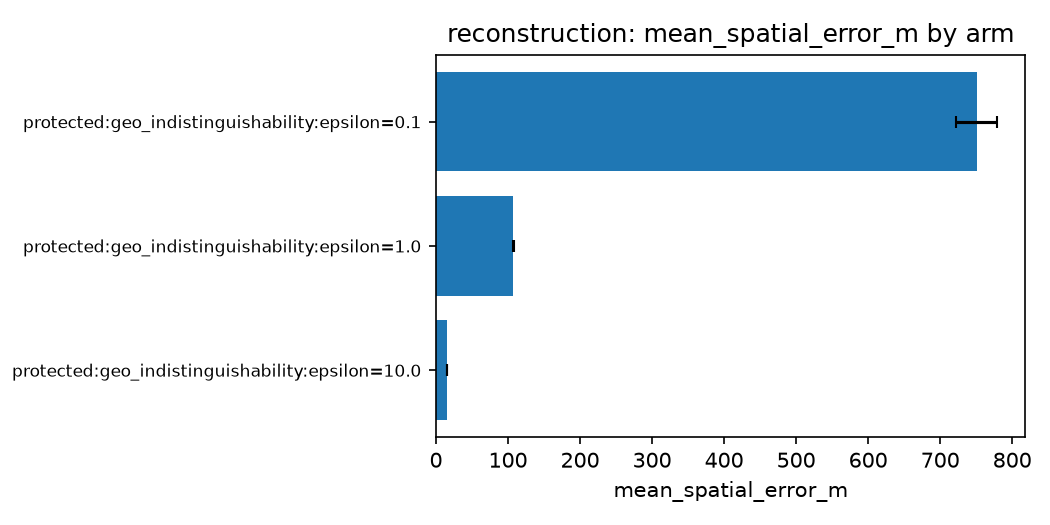

u20: mechanisms_reidentification.png


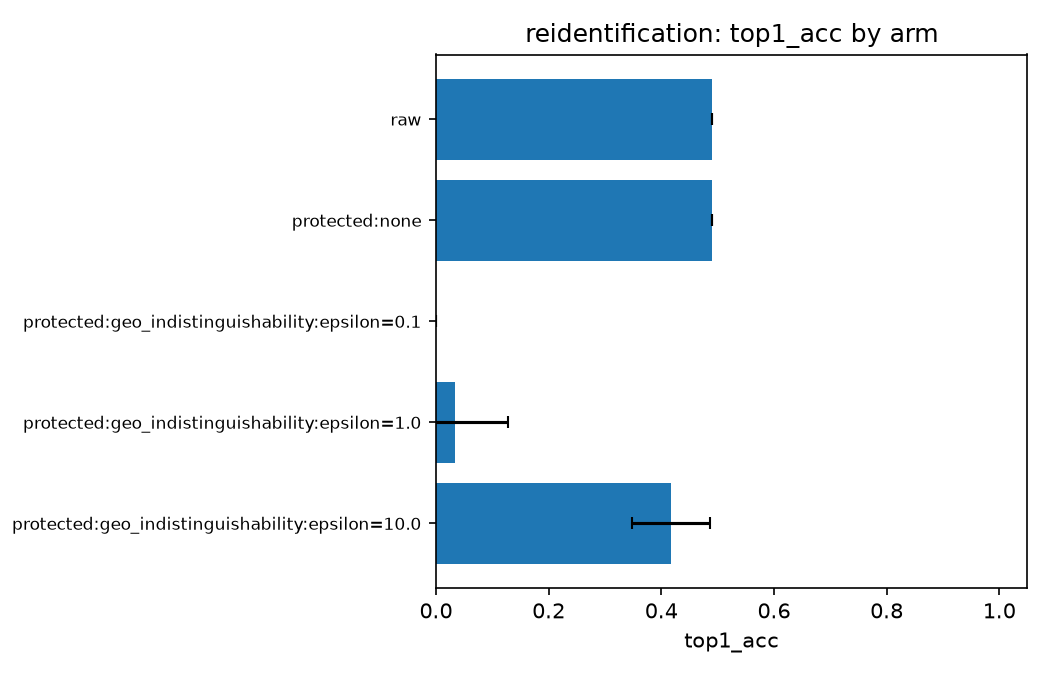

u50: mechanisms_membership_inference.png


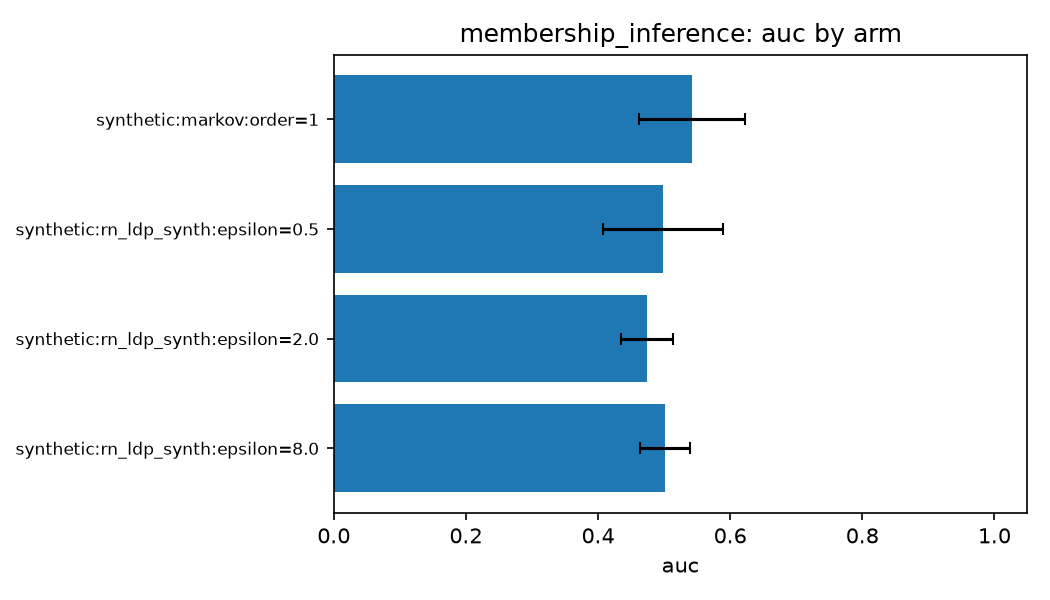

u50: mechanisms_poi_inference.png


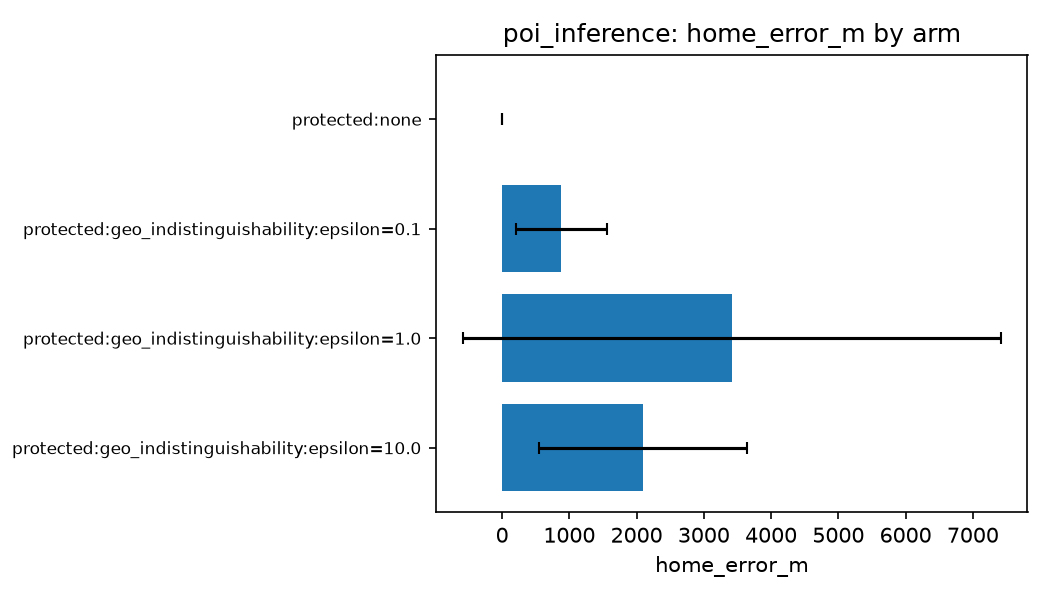

u50: mechanisms_reconstruction.png


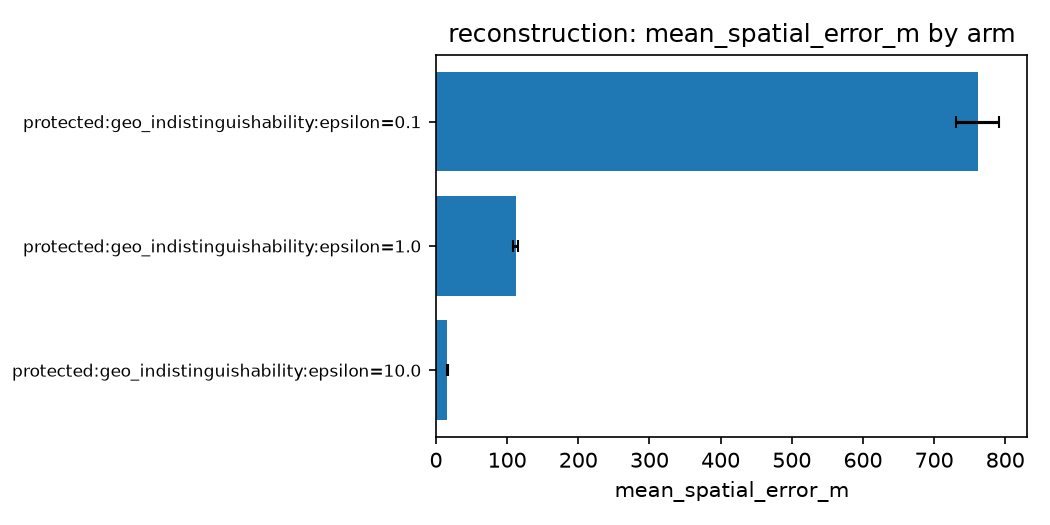

u50: mechanisms_reidentification.png


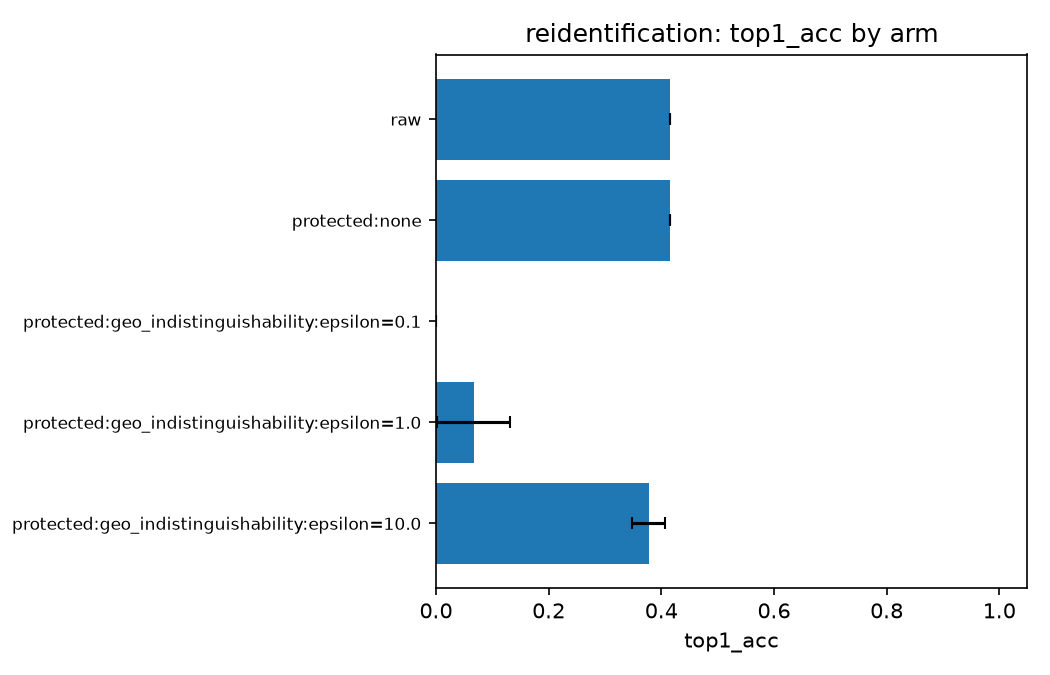

In [6]:
for rung in rungs:
    for path in plot_mechanisms(agg_by_rung[rung], rung_dir(rung)):
        print(f"u{rung}: {path.name}")
        display(Image(filename=str(path)))

## 7 · Računski čas

Čas enega zagona napada (povprečje čez semena, logaritemska os, barva po
družini). Pozor: privzeto vklopljeno merjenje pomnilniške špice
(`metrics.memory`) čas napada približno podvoji — za časovno merodajne
primerjave poganjaj z `metrics: {memory: false}` (`docs/RUNNING.md` §7.3, R0).


u20: runtime.png


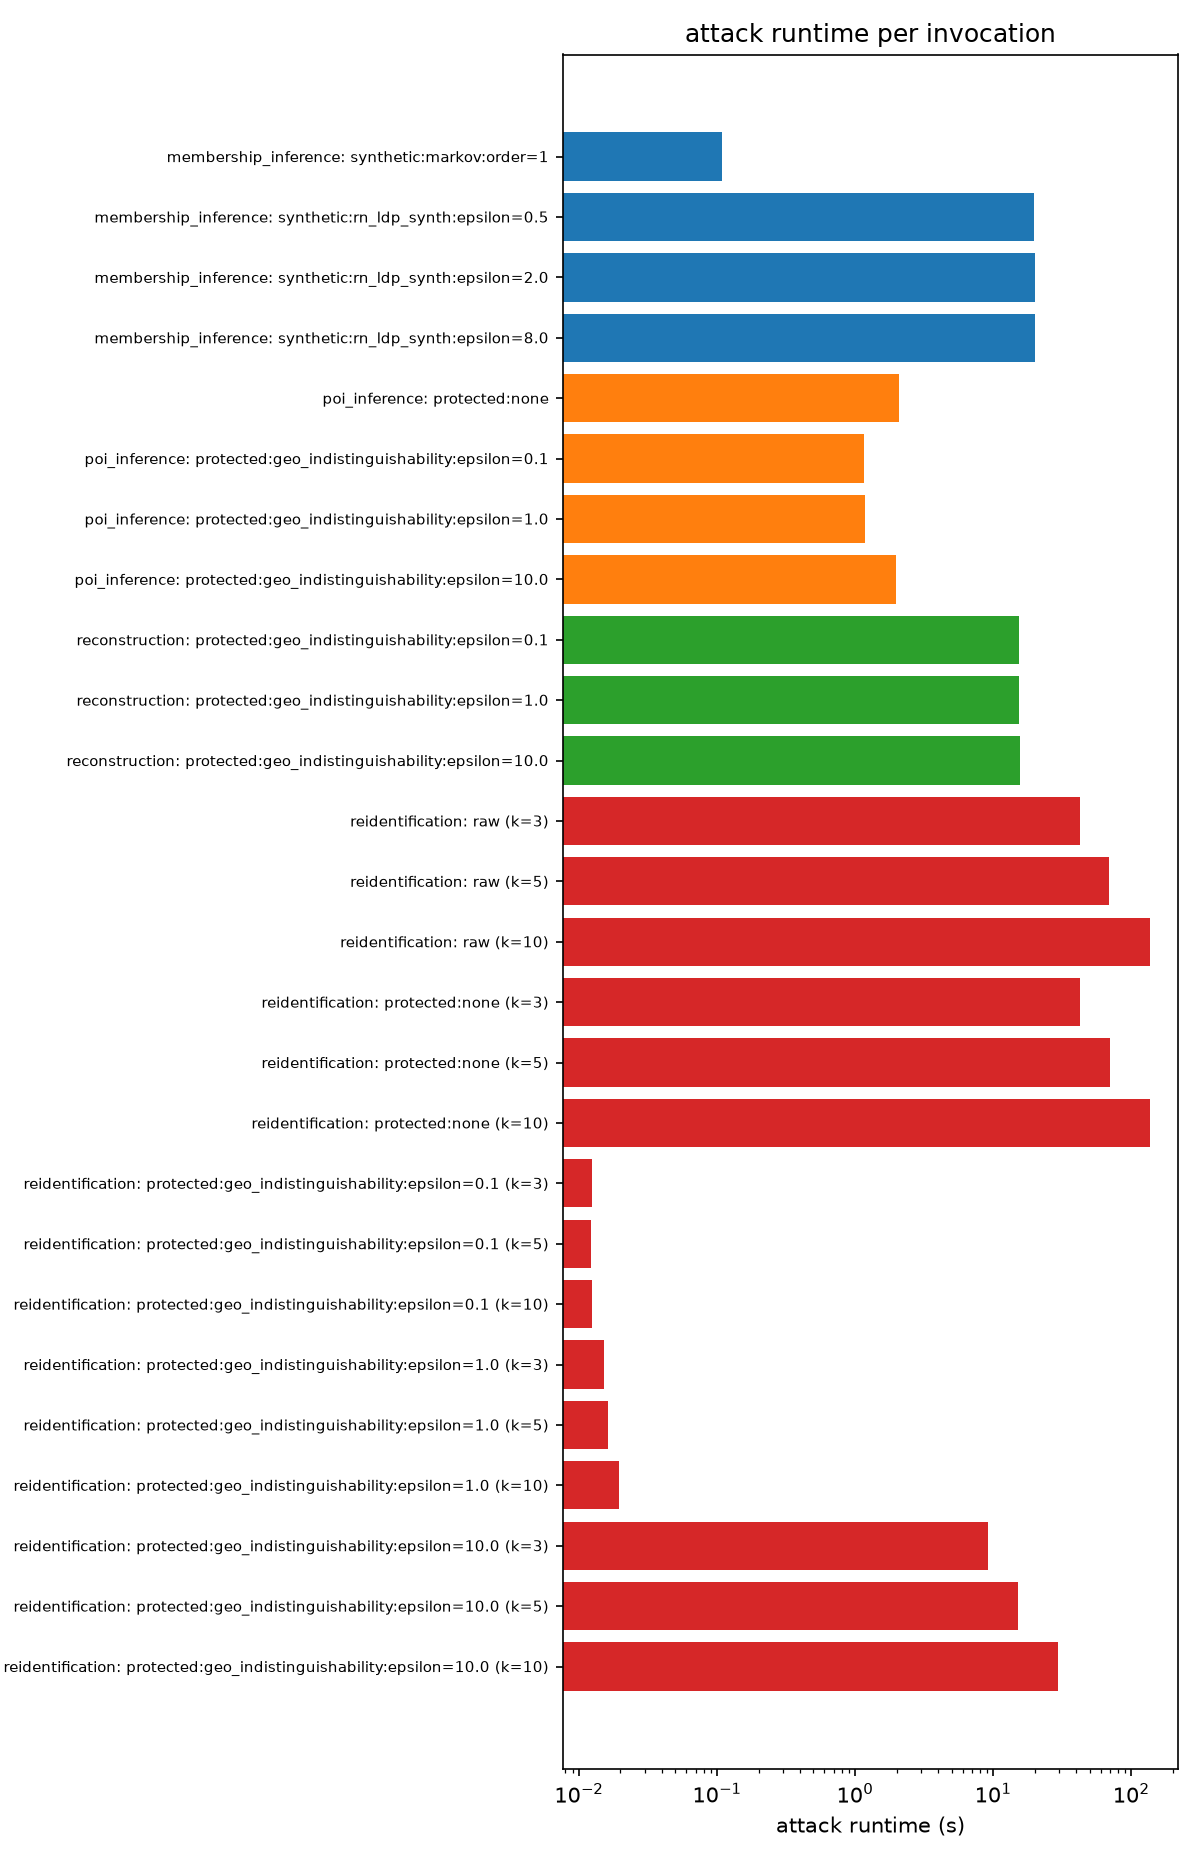

u50: runtime.png


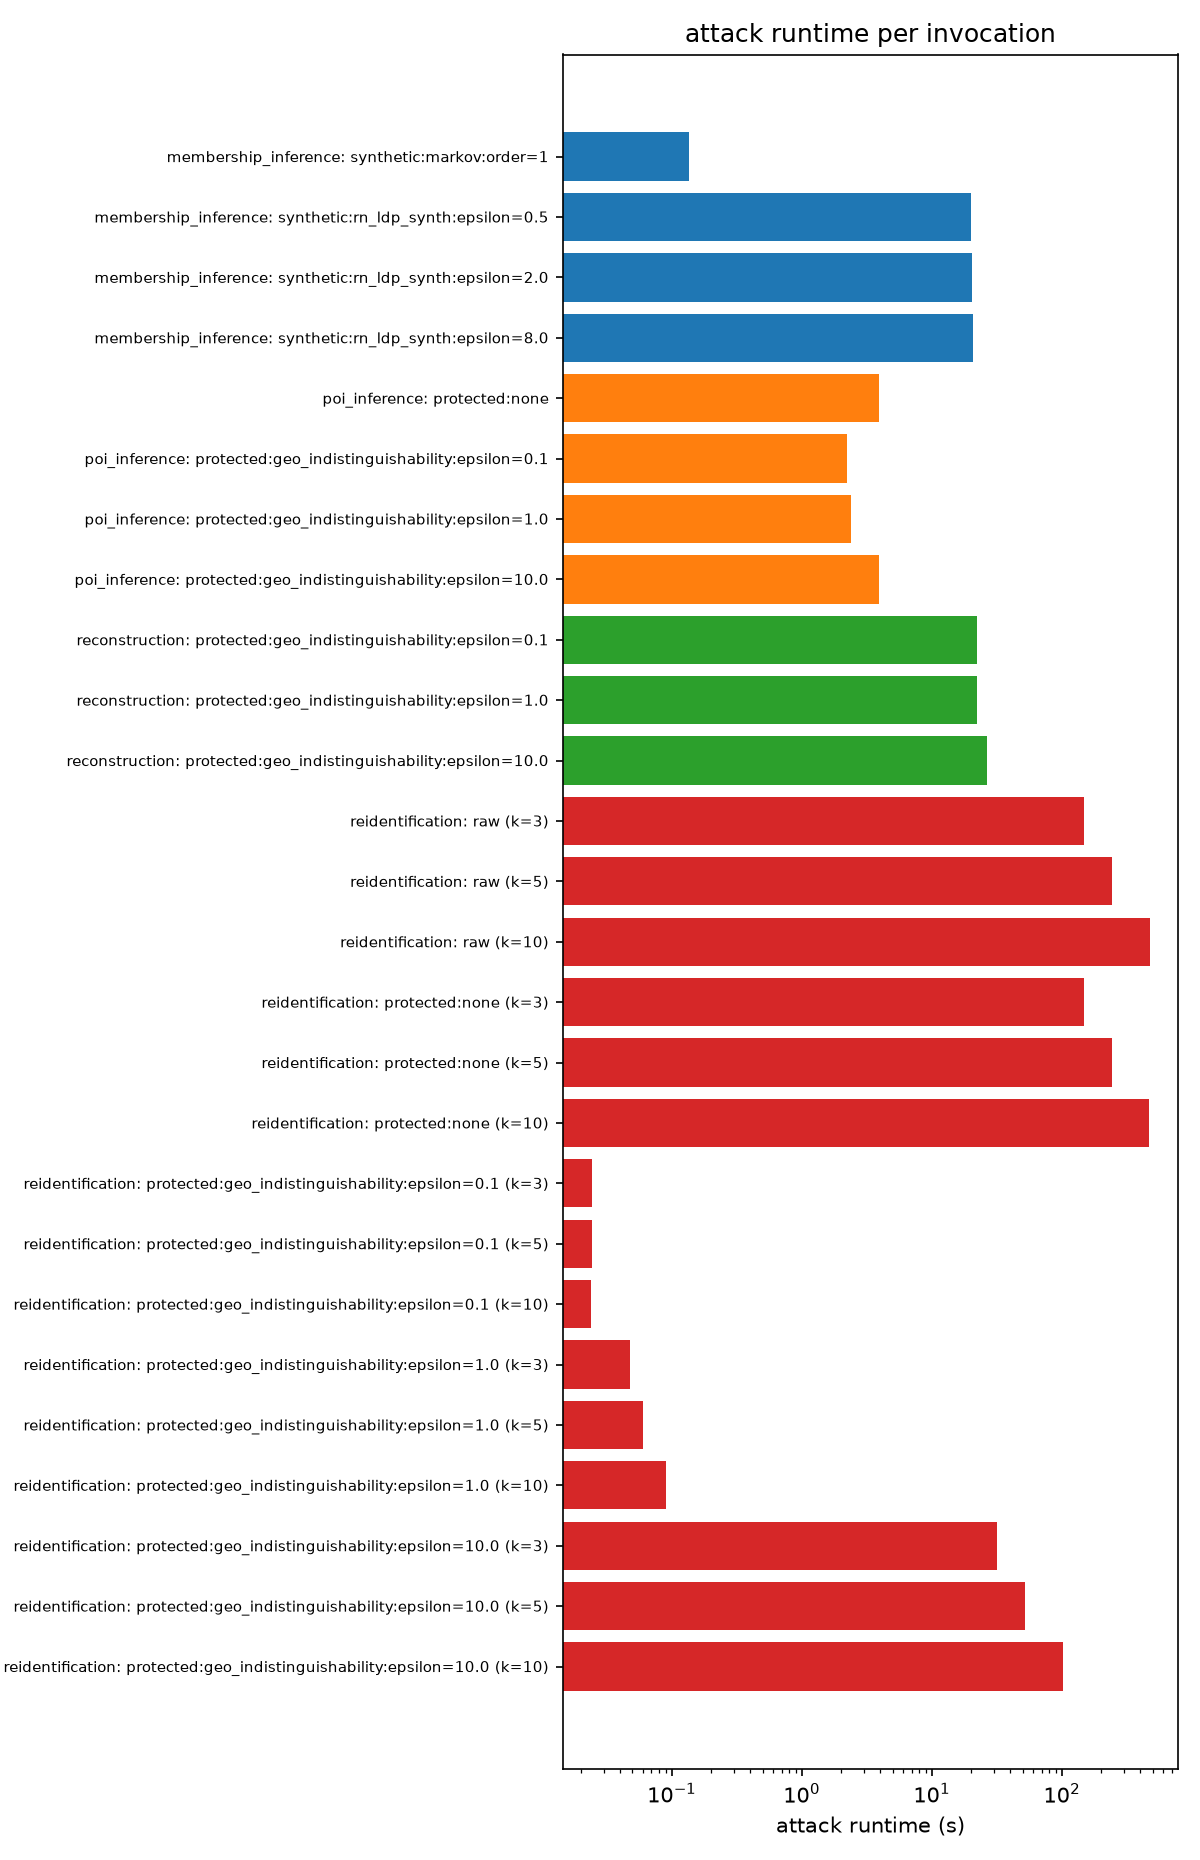

In [7]:
for rung in rungs:
    for path in plot_runtime(agg_by_rung[rung], rung_dir(rung)):
        print(f"u{rung}: {path.name}")
        display(Image(filename=str(path)))

## 8 · Pregled računskega proračuna (X = 300 s)

Orkestrator vsako prekoračitev proračuna zabeleži v `run.json` (blok
`over_budget`); zagona nikoli ne prekine in rezultatov ne krči. Ta pregled
zbere prekoračitve iz vseh zagonov — uporabi ga pri načrtovanju *naslednjih*
zagonov kampanje po lestvi krčenja iz `docs/RUNNING.md` §7.3. Stolpec
`memory_traced` opozarja, da je bil čas izmerjen z vklopljenim sledenjem
pomnilnika in je zato napihnjen (pravilo R0).


In [8]:
import json

offenders = []
for run_json in sorted(RESULTS_DIR.rglob("run.json")):
    data = json.loads(run_json.read_text())
    block = data.get("over_budget") or {}
    for off in block.get("attacks", []):
        offenders.append(
            {
                "run": str(run_json.parent.relative_to(RESULTS_DIR)),
                "result_id": off["result_id"],
                "runtime_s": off["runtime_s"],
                "budget_s": block.get("budget_s"),
                "memory_traced": block.get("memory_traced"),
            }
        )
if offenders:
    display(pd.DataFrame(offenders).sort_values("runtime_s", ascending=False))
    print(
        "Lestev krcenja (docs/RUNNING.md, razdelek 7.3), korak za korakom:\n"
        " 1. dataset.max_users stopnjo nizje po lestvi 182 -> 100 -> 50 -> 20;\n"
        " 2. nato druzinski gumb: MIA prepolovi n_shadow (ne pod 8), "
        "reidentifikacija opusti najvecji known_points;\n"
        " 3. kar ostane nad proracunom, se iz kampanje izloci in izlocitev "
        "(z izmerjenim casom) zabelezi."
    )
else:
    print("Nobena invokacija napada ni prekoracila proracuna 300 s.")

,run,result_id,runtime_s,budget_s,memory_traced
8,geolife_geoind_reid_u50\seed5,reidentification:raw:k10,475.172,300.0,False
9,geolife_geoind_reid_u50\seed5,reidentification:protected:none:k10,473.541,300.0,False
6,geolife_geoind_reid_u50\seed4,reidentification:raw:k10,473.203,300.0,False
7,geolife_geoind_reid_u50\seed4,reidentification:protected:none:k10,472.508,300.0,False
4,geolife_geoind_reid_u50\seed3,reidentification:raw:k10,471.876,300.0,False
5,geolife_geoind_reid_u50\seed3,reidentification:protected:none:k10,470.878,300.0,False
2,geolife_geoind_reid_u50\seed2,reidentification:raw:k10,470.710,300.0,False
3,geolife_geoind_reid_u50\seed2,reidentification:protected:none:k10,470.428,300.0,False
0,geolife_geoind_reid_u50\seed1,reidentification:raw:k10,467.836,300.0,False
1,geolife_geoind_reid_u50\seed1,reidentification:protected:none:k10,467.105,300.0,False


Lestev krcenja (docs/RUNNING.md, razdelek 7.3), korak za korakom:
 1. dataset.max_users stopnjo nizje po lestvi 182 -> 100 -> 50 -> 20;
 2. nato druzinski gumb: MIA prepolovi n_shadow (ne pod 8), reidentifikacija opusti najvecji known_points;
 3. kar ostane nad proracunom, se iz kampanje izloci in izlocitev (z izmerjenim casom) zabelezi.


## 9 · Diagnostika praga ujemanja (S4-1)

Ta celica je podlaga za izbiro `map_matching.min_match_score` po odločitvi S4-1
(`docs/HANDOFF_S4_POPRAVKI.md` §1): populacija poročila so vozne sledi,
definirane operativno kot sledi z oceno ujemanja `match_score ≥ prag`, prag pa
se izbere iz izmerjene porazdelitve ocen, ne na slepo. Diagnostika teče **na
vsaki izmerjeni stopnji lestvice vzorca** posebej:

- **Stopnja 20** (izvirna diagnostika, 16. avgust 2026): produkcijski cevovod
  do ujemanja s pragom 0.0, tako da vsaka očiščena sled obdrži svojo oceno in
  histogram pokrije celotno porazdelitev (85 % očiščenih sledi se na vozno
  omrežje sploh ne ujame). Iz te tabele je bil izbran prag 0.05.
- **Stopnja 50** (dodano 17. avgusta 2026): meritev avtorjeve zabeležke iz
  PR 3 — ali bi od stopnje 50 naprej zadoščal strožji prag **0.5**
  (`docs/RUNNING.md` §7.4). Tu se ponovno uporabi kar **bazen eksperimenta s
  pragom 0.05** (topel predpomnilnik zagona stopnje 50): vse sledi z oceno
  ≥ 0.05 so v njem, zato je tabela za kandidatne prage ≥ 0.05 popolna in
  točna. Nov hladen prehod čiščenja in ujemanja s pragom 0.0 bi stal ure in
  za vprašanje praga 0.5 ne bi dodal ničesar (avtorjeva odločitev, 17. avgust
  2026); histogram zato prikazuje samo ocene ≥ 0.05, masa pod 0.05 pa je
  dokumentirana s histogramom stopnje 20 (delež preživetja od `max_users` ni
  odvisen, S4-1). Izid meritve: prag 0.5 se NI potrdil (projekcija 81 nečlanov
  pri 182 < 100); avtor je 17. avgusta 2026 za poročevalski pogon izbral prag
  **0.3** (projekcija 118 nečlanov, z rezervo nad mejo 100).
- **Stopnja 182** (dodano 18. avgusta 2026): poročevalski pogon s pragom
  **0.3**. Diagnostika ponovno uporabi bazen eksperimenta (topel predpomnilnik
  pogona stopnje 182), zato je tabela popolna za kandidatne prage ≥ 0.3;
  nižji pragi so dokumentirani s tabelama stopenj 20 in 50. S tem je meja
  populacije izmerjena na stopnji, na kateri poročilo poroča, ne zgolj
  projicirana z manjše.

**Kako brati izpis.** Za vsako stopnjo: histogram ocen, nato tabela, ki za
vsak kandidatni prag pove, koliko sledi preživi, koliko uporabnikov pokrijejo,
koliko nečlanov (razrez `test`) ostane za napad na članstvo in grobo projekcijo
nečlanov pri polnem obsegu 182 uporabnikov (nečlani ≈ 0,2 × preživetje ×
očiščene sledi pri 182; izpeljava v `docs/HANDOFF_S4_POPRAVKI.md` §S4-2).
Stopnja 20 za projekcijo obdrži izvirno predpostavko 14 600 očiščenih sledi
pri 182 (dokaz izbire praga ostane nespremenjen), stopnji 50 in 182 pa oceno
izpeljeta iz lastnega izmerjenega števila očiščenih sledi (pri 182 projekcija
sovpade z izmerjenim štetjem `test` razreza). Merilo validacijskega pogona
pri 20 (`docs/HANDOFF_S4_POPRAVKI.md` §2): vsaj 11 nečlanov in pokritih vsaj
15 od 20 uporabnikov. Za odločitev o pragu poročevalskega pogona je ključna
tabela stopnje 50; tabela stopnje 182 je izmerjena meja populacije poročila.

Diagnostika teče na avtorjevem okolju (surovi Geolife podatki niso v
repozitoriju); izvedeni izpisi v tem zvezku so dokaz, na katerem temeljita
izbrani prag in meritev za morebitni strožji prag.

In [9]:
import dataclasses
import logging

import matplotlib.pyplot as plt
import numpy as np

from trajguard.experiments.orchestrator import _matched_pool, _net_provider, load_config

logging.disable(logging.WARNING)  # silence leuven's linear-search notices

# The YAML's paths are relative to the repo root; this notebook runs in notebooks/.
ROOT = Path("..").resolve()

# One diagnostic per sample-ladder rung (see the section text for the rationale):
# (config, rung, forced pool threshold or None to keep the YAML's, cleaned-at-182
# for the projection or None to derive it from the rung's own cleaned count, figure).
RUNG_SPECS = [
    ("geolife_geoind_reid_u20.yaml", 20, 0.0, 14_600, "match_score_diagnostic.png"),
    ("geolife_geoind_reid_u50.yaml", 50, None, None, "match_score_diagnostic_u50.png"),
    ("geolife_geoind_reid.yaml", 182, None, None, "match_score_diagnostic_u182.png"),
]
candidate_thresholds = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for config_name, rung, forced_threshold, cleaned_at_182, figure_name in RUNG_SPECS:
    cfg = load_config(ROOT / "config" / "experiments" / config_name)
    cfg = dataclasses.replace(
        cfg,
        min_match_score=cfg.min_match_score if forced_threshold is None else forced_threshold,
        output_dir=ROOT / cfg.output_dir,
        cache_dir=ROOT / cfg.cache_dir,
        protected_dir=ROOT / cfg.protected_dir,
        map_dir=ROOT / cfg.map_dir,
        dataset_path=ROOT / cfg.dataset_path,
    )
    matched, clean_by_id, dropped, split_counts = _matched_pool(cfg, _net_provider(cfg))
    scores = pd.DataFrame(
        {
            "user_id": [m.user_id for m in matched],
            "match_score": [m.match_score for m in matched],
            "split": [clean_by_id[m.traj_id].split for m in matched],
        }
    )
    n_cleaned = len(matched) + dropped  # dropped = cleaned traces below the pool threshold
    if cleaned_at_182 is None:
        cleaned_at_182 = round(n_cleaned * 182 / rung)
    print(
        f"--- stopnja u{rung} (prag bazena {cfg.min_match_score:g}) ---\n"
        f"cleaned trajectories: {n_cleaned} from {rung} users "
        f"(pool keeps {len(matched)}, dropped {dropped}); "
        f"splits over cleaned: {split_counts}; "
        f"cleaned at 182 for the projection: {cleaned_at_182}"
    )

    # Non-member projection at full scale, HANDOFF_S4_POPRAVKI.md §S4-2:
    # non-members ~ test fraction (0.2) x survival rate x cleaned trajectories at
    # 182 users. The 0.2 is the *user* fraction, so this is an expectation, not a
    # guarantee (the realised per-trace test share differs).
    TEST_FRACTION = cfg.fractions["test"]
    thresholds = [t for t in candidate_thresholds if t >= cfg.min_match_score]
    table = pd.DataFrame(
        {
            "prag": t,
            "prezivele sledi": int((scores["match_score"] >= t).sum()),
            "prezivetje %": round(100 * (scores["match_score"] >= t).sum() / n_cleaned, 1),
            f"pokriti uporabniki (od {rung})": scores.loc[
                scores["match_score"] >= t, "user_id"
            ].nunique(),
            f"neclani (test) pri {rung}": int(
                ((scores["match_score"] >= t) & (scores["split"] == "test")).sum()
            ),
            "projekcija neclanov pri 182": round(
                TEST_FRACTION * (scores["match_score"] >= t).sum() / n_cleaned * cleaned_at_182
            ),
        }
        for t in thresholds
    )

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(scores["match_score"], bins=np.arange(0.0, 1.025, 0.025), color="#5B7DB1", zorder=2)
    for t in thresholds:
        ax.axvline(t, color="#8A8A8A", linestyle="--", linewidth=1, zorder=3)
        ax.text(
            t, ax.get_ylim()[1] * 0.97, f"{t:g}", ha="center", va="top", fontsize=8, color="#555"
        )
    ax.set_xlabel("match_score")
    ax.set_ylabel("stevilo sledi")
    note = (
        ""
        if cfg.min_match_score == 0.0
        else f"; bazen praga {cfg.min_match_score:g}, ocene pod njim niso prikazane"
    )
    ax.set_title(f"Porazdelitev match_score, {Path(config_name).stem} (n = {len(scores)}{note})")
    ax.grid(axis="y", color="#E3E3E3", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / figure_name, dpi=150)
    display(fig)
    plt.close(fig)
    display(table)

--- stopnja u20 (prag bazena 0) ---
cleaned trajectories: 1607 from 20 users (pool keeps 1607, dropped 0); splits over cleaned: {'train': 556, 'shadow': 897, 'test': 142, 'attack': 12}; cleaned at 182 for the projection: 14600


<Figure size 900x450 with 1 Axes>

,prag,prezivele sledi,prezivetje %,pokriti uporabniki (od 20),neclani (test) pri 20,projekcija neclanov pri 182
0,0.05,236,14.7,16,15,429
1,0.10,171,10.6,15,10,311
2,0.15,141,8.8,14,8,256
3,0.20,125,7.8,14,7,227
4,0.30,92,5.7,12,4,167
5,0.40,78,4.9,11,3,142
6,0.50,64,4.0,11,3,116
7,0.60,45,2.8,9,3,82
8,0.70,20,1.2,7,2,36


--- stopnja u50 (prag bazena 0.05) ---
cleaned trajectories: 3243 from 50 users (pool keeps 465, dropped 2778); splits over cleaned: {'shadow': 1234, 'attack': 1045, 'test': 281, 'train': 683}; cleaned at 182 for the projection: 11805


<Figure size 900x450 with 1 Axes>

,prag,prezivele sledi,prezivetje %,pokriti uporabniki (od 50),neclani (test) pri 50,projekcija neclanov pri 182
0,0.05,465,14.3,41,33,339
1,0.10,333,10.3,38,24,242
2,0.15,272,8.4,37,19,198
3,0.20,229,7.1,36,17,167
4,0.30,162,5.0,33,12,118
5,0.40,137,4.2,30,10,100
6,0.50,111,3.4,30,8,81
7,0.60,78,2.4,24,6,57
8,0.70,43,1.3,20,3,31


## Kam naprej

- Nove zagone kampanje poganjaj s `trajguard repeat` (`docs/RUNNING.md` §7.1)
  in osveži ta zvezek headlessly (ukaz v uvodu).
- Rezultati na fixture podatkih (2 uporabnika, 8 poti) so statistično
  nepomembni — služijo samo kot dokaz, da vsak korak teče (`docs/RUNNING.md`
  §5). Za poročilo uporabi zagone na pravem Geolife naboru.
- Za prenos v Word: slike so v `reports/s4_figures/`, tabele izvoziš iz
  pandas (`DataFrame.to_csv` / `to_clipboard`), celoten zvezek pa z
  `uv run jupyter nbconvert --to html --no-input notebooks/03_s4_sweep.ipynb`.
